In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [2]:
print("Problem Statement:")
print("Build machine learning models that classify Iris flowers as Setosa, Versicolor, or Virginica using flower measurements.")

Problem Statement:
Build machine learning models that classify Iris flowers as Setosa, Versicolor, or Virginica using flower measurements.


In [3]:
iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="species")

df = X.copy()
df["species"] = y

df.to_csv("Task5_Iris_Dataset.csv", index=False)

print("Dataset saved as Task5_Iris_Dataset.csv")
df.head()

Dataset saved as Task5_Iris_Dataset.csv


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nClass counts:")
print(df["species"].value_counts().sort_index())

print("\nClass names:")
print("0 = Setosa")
print("1 = Versicolor")
print("2 = Virginica")

Dataset shape: (150, 5)

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Class counts:
species
0    50
1    50
2    50
Name: count, dtype: int64

Class names:
0 = Setosa
1 = Versicolor
2 = Virginica


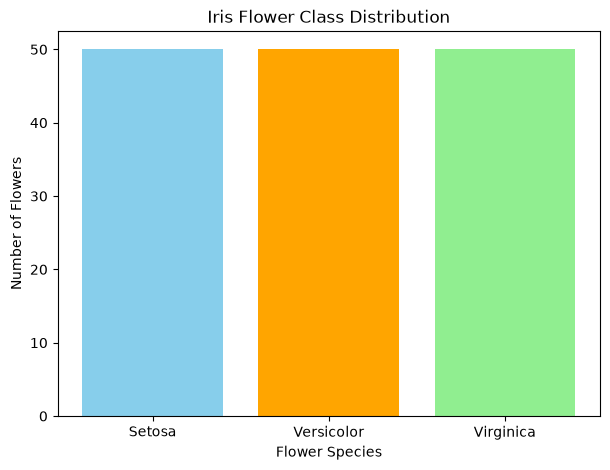

In [5]:
class_counts = df["species"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(
    ["Setosa", "Versicolor", "Virginica"],
    class_counts.values,
    color=["skyblue", "orange", "lightgreen"]
)

plt.title("Iris Flower Class Distribution")
plt.xlabel("Flower Species")
plt.ylabel("Number of Flowers")
plt.show()

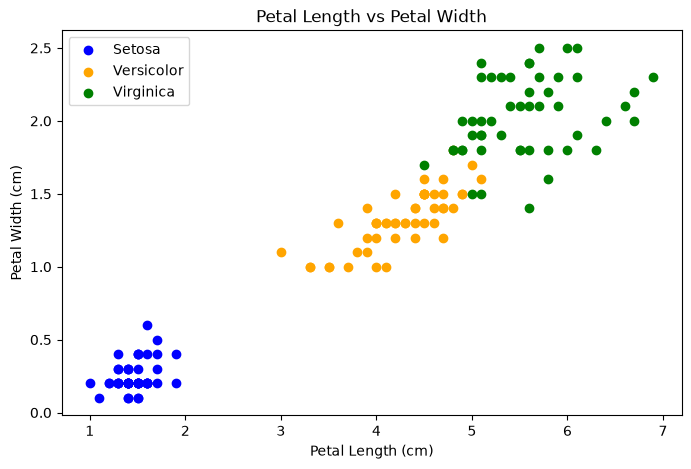

In [6]:
plt.figure(figsize=(8, 5))

for species_number, species_name, color in [
    (0, "Setosa", "blue"),
    (1, "Versicolor", "orange"),
    (2, "Virginica", "green")
]:
    species_data = df[df["species"] == species_number]

    plt.scatter(
        species_data["petal length (cm)"],
        species_data["petal width (cm)"],
        label=species_name,
        color=color
    )

plt.title("Petal Length vs Petal Width")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.legend()
plt.show()

In [7]:
X = df.drop("species", axis=1)
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (120, 4)
Testing data shape: (30, 4)


In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logistic_model = LogisticRegression(max_iter=200)

logistic_model.fit(X_train_scaled, y_train)

logistic_predictions = logistic_model.predict(X_test_scaled)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [9]:
tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=3
)

tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [10]:
logistic_accuracy = accuracy_score(y_test, logistic_predictions)
logistic_precision = precision_score(
    y_test,
    logistic_predictions,
    average="weighted",
    zero_division=0
)
logistic_recall = recall_score(
    y_test,
    logistic_predictions,
    average="weighted",
    zero_division=0
)

print("LOGISTIC REGRESSION RESULTS")
print("Accuracy:", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall:", logistic_recall)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=iris.target_names
    )
)

LOGISTIC REGRESSION RESULTS
Accuracy: 0.9333333333333333
Precision: 0.9333333333333333
Recall: 0.9333333333333333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [11]:
tree_accuracy = accuracy_score(y_test, tree_predictions)
tree_precision = precision_score(
    y_test,
    tree_predictions,
    average="weighted",
    zero_division=0
)
tree_recall = recall_score(
    y_test,
    tree_predictions,
    average="weighted",
    zero_division=0
)

print("DECISION TREE RESULTS")
print("Accuracy:", tree_accuracy)
print("Precision:", tree_precision)
print("Recall:", tree_recall)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        tree_predictions,
        target_names=iris.target_names
    )
)

DECISION TREE RESULTS
Accuracy: 0.9666666666666667
Precision: 0.9696969696969696
Recall: 0.9666666666666667

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



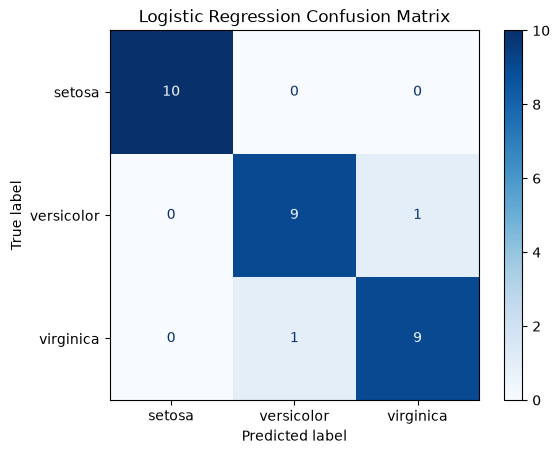

In [12]:
logistic_cm = confusion_matrix(y_test, logistic_predictions)

logistic_display = ConfusionMatrixDisplay(
    confusion_matrix=logistic_cm,
    display_labels=iris.target_names
)

logistic_display.plot(cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")
plt.show()

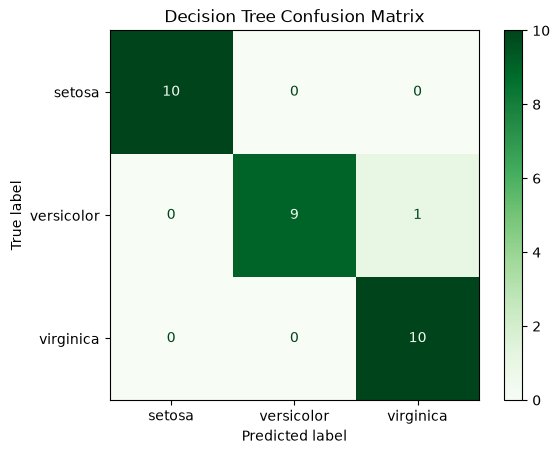

In [13]:
tree_cm = confusion_matrix(y_test, tree_predictions)

tree_display = ConfusionMatrixDisplay(
    confusion_matrix=tree_cm,
    display_labels=iris.target_names
)

tree_display.plot(cmap="Greens")

plt.title("Decision Tree Confusion Matrix")
plt.show()

In [14]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [logistic_accuracy, tree_accuracy],
    "Precision": [logistic_precision, tree_precision],
    "Recall": [logistic_recall, tree_recall]
})

model_comparison

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.933333,0.933333,0.933333
1,Decision Tree,0.966667,0.969697,0.966667


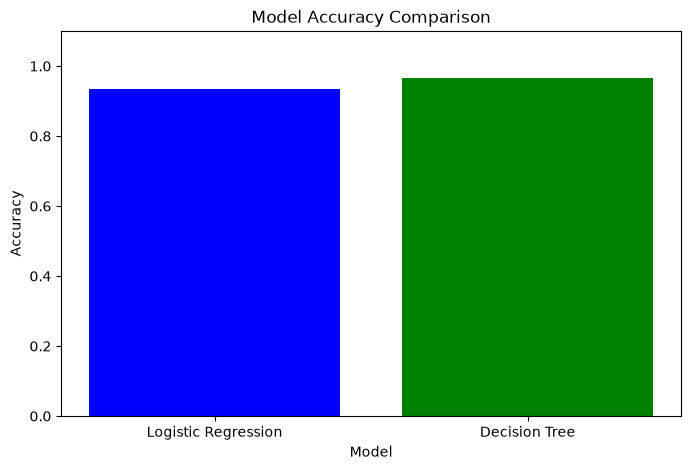

In [15]:
plt.figure(figsize=(8, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["Accuracy"],
    color=["blue", "green"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1.1)
plt.show()

In [16]:
best_model = model_comparison.loc[
    model_comparison["Accuracy"].idxmax(),
    "Model"
]

best_accuracy = model_comparison["Accuracy"].max()

print("FINAL CONCLUSION")
print("Best model:", best_model)
print("Best accuracy:", best_accuracy)
print("The selected model has the highest test accuracy.")
print("A limitation is that the Iris dataset is small and may not represent real-world flower variation.")

FINAL CONCLUSION
Best model: Decision Tree
Best accuracy: 0.9666666666666667
The selected model has the highest test accuracy.
A limitation is that the Iris dataset is small and may not represent real-world flower variation.


CONCLUSION

This project builds and compares two Machine Learning classification models to predict Iris flower species (Setosa, Versicolor, Virginica) based on four flower measurements: sepal length, sepal width, petal length, and petal width. The dataset used is the well-known Iris dataset (150 samples, perfectly balanced across three classes, no missing values), sourced from scikit-learn's built-in datasets.

Two models were selected: Logistic Regression (with feature scaling via StandardScaler) and a Decision Tree Classifier (max depth of 3, to avoid overfitting). Both models were trained on 80% of the data and evaluated on the remaining 20%, using stratified sampling to ensure balanced class representation in both sets.

Logistic Regression achieved 93.3% accuracy, while the Decision Tree Classifier performed slightly better at 96.7% accuracy, with stronger precision and recall particularly for the Virginica class. Confusion matrices showed both models occasionally confused Versicolor and Virginica, which is expected since these two species have overlapping petal measurements, as seen in the scatter plot visualization.

Based on these results, the Decision Tree Classifier was selected as the better-performing model for this dataset. However, a key limitation is that the Iris dataset is small (150 samples) and clean, which may not reflect the noise and complexity of real-world data. Future improvements could include testing on a larger, more realistic dataset, tuning hyperparameters (such as tree depth) more systematically using cross-validation, and comparing additional models such as KNN or Random Forest to see if performance improves further.